# Aufgabe 3 - Tiefe Einblicke ins Institut: Reloaded

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

In [300]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F  
import torchvision.transforms as T
import torch.optim as optim
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import copy


## Teilaufgabe a): Trainings-, Test-und Validierungsdatenset

In [301]:
rooms = ['Flur', 'Labor', 'Professorenbuero', 'Teekueche']
training_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(1,16)]  # ["./pfad/zu/bildA.png","./pfad/zu/bildB.png",...]
validation_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(16, 20)] # ["./pfad/zu/bildZ.png","./pfad/zu/bildY.png",...]
test_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(20, 26)] # ["./pfad/zu/bildC.png","./pfad/zu/bildD.png",...]


## Teilaufgabe b): CNN definieren und implementieren

In [307]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        
        # Am Ende haben wir 64 Filter auf einer Bildgröße von 8x8 Pixeln.
        # Das ergibt flachgedrückt: 64 * 8 * 8 = 4096 Features.
        self.fc1 = nn.Linear(4096, 128) # Feature-Kombination
        self.fc2 = nn.Linear(128, 4)    # Klassifikation in 4 Raumklassen
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(-1, x.size(1))
        
        return x
    

## Teilaufgabe c): Training und Test mit CNN

Datenset-Klasse um mit Pytorch Bilder zu laden. 

Input sind: 
- Liste mit Pfaden zu Bildern
- Liste mit dazugehörigen Labels (numerisch darstellen!) 
- Transformation der Bilder


In [308]:
class ROBDataset(Dataset):
    def __init__(self, img_path_list, img_labels, transform=None):
        # Pfade zu den Bildern als list
        self.img_path_list = img_path_list
        
        # Dazugehörige Labels zu den Bildern als list
        self.img_labels = img_labels
        
        # Transformations der Bilder
        self.transform = transform

    def __len__(self):
        return len(self.img_path_list)

    def __getitem__(self, idx):
        # Bild laden
        img_path = self.img_path_list[idx]
        image = read_image(img_path)
        
        # Label laden
        label = self.img_labels[idx]
        
        # Transformieren
        if self.transform:
            image = self.transform(image)
            
        return image.float(), int(label)

Trainingsiteration über alle Bilder.

Inputs sind:
- Pytorch dataloader Object über das iteriert wird
- bool do_backprob Parameter um Backpropagation durchzuführen oder nicht

In [309]:
# Iterating over the entire data set once
def run_iteration(dataloader, do_backprob=True):
    global net, optimizer, criterion
    loss_iter = []
    acc_iter = []
    for batch_x, batch_y in dataloader:
        # To device
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward + backward + optimize
        y_predict = net(batch_x)
        loss = criterion(y_predict, batch_y)
        if do_backprob:
            loss.backward()
            optimizer.step()

        # statistics
        loss_iter.append(loss.detach().cpu().numpy())
        
        _, predicted = torch.max(torch.softmax(y_predict, dim=1),1)
        
        acc_iter.append(accuracy_score(batch_y.detach().cpu().numpy(), 
                                       predicted.detach().cpu().numpy()))
    
    return np.mean(loss_iter), np.mean(acc_iter)

Komplette Durchführung eines Trainings
Die Variablen y_train, y_val und y_test müssen noch gesetzt werden. Diese Listen beinhalten die entsprechenden Labels als numerische Darstellung.

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 4.0758348
	Train Acc.	 0.2
	Val Loss	 3.8661027
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 3.2817025
	Train Acc.	 0.25
	Val Loss	 2.2264857
	Val Acc.	 0.25
Epoch 3 from 100
	Train Loss	 1.8800162
	Train Acc.	 0.21666666666666667
	Val Loss	 1.438524
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.5121709
	Train Acc.	 0.25
	Val Loss	 1.3962321
	Val Acc.	 0.3125
Epoch 5 from 100
	Train Loss	 1.4955615
	Train Acc.	 0.18333333333333332
	Val Loss	 1.359127
	Val Acc.	 0.25
Epoch 6 from 100
	Train Loss	 1.4043386
	Train Acc.	 0.26666666666666666
	Val Loss	 1.347966
	Val Acc.	 0.3125
Epoch 7 from 100
	Train Loss	 1.3862643
	Train Acc.	 0.31666666666666665
	Val Loss	 1.3343017
	Val Acc.	 0.375
Epoch 8 from 100
	Train Loss	 1.439775
	Train Acc.	 0.23333333333333334
	Val Loss	 1.2995085
	Val Acc.	 0.4375
Epoch 9 from 100
	Train Loss	 1.3364564
	Train Acc.	 0.4166666666666667
	Val Loss	 1.2594233
	Val Acc.	 0.4375
Epoch 10 from 100


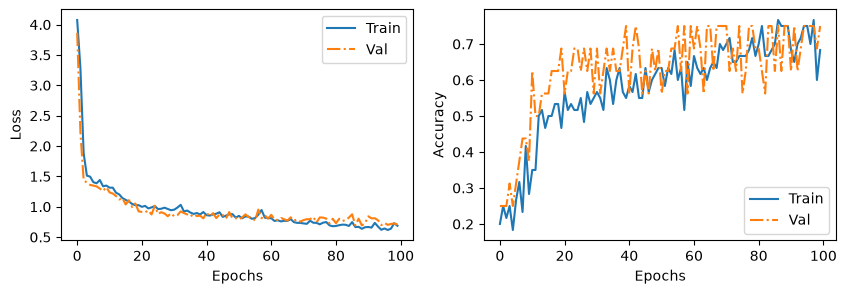

In [310]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [311]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [312]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.5833333333333334
Precision: 0.49220779220779215
Recall   : 0.5833333333333334
F1       : 0.521184697655286


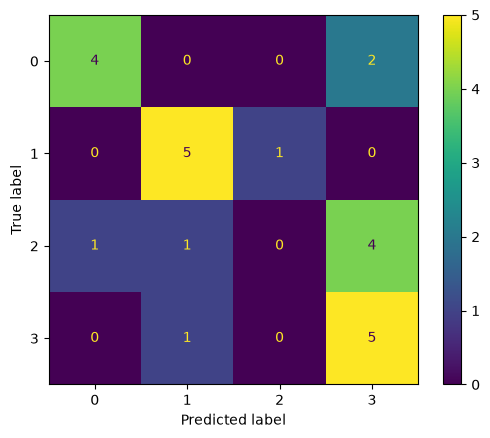

In [313]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe d): Augmentierung

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 3.9702394
	Train Acc.	 0.16666666666666666
	Val Loss	 3.489972
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 2.5410492
	Train Acc.	 0.25
	Val Loss	 1.7341989
	Val Acc.	 0.25
Epoch 3 from 100
	Train Loss	 1.4960209
	Train Acc.	 0.23333333333333334
	Val Loss	 1.4237213
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.4626124
	Train Acc.	 0.13333333333333333
	Val Loss	 1.3967342
	Val Acc.	 0.3125
Epoch 5 from 100
	Train Loss	 1.4994161
	Train Acc.	 0.26666666666666666
	Val Loss	 1.39785
	Val Acc.	 0.25
Epoch 6 from 100
	Train Loss	 1.4988039
	Train Acc.	 0.25
	Val Loss	 1.3374519
	Val Acc.	 0.4375
Epoch 7 from 100
	Train Loss	 1.4062198
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3985542
	Val Acc.	 0.25
Epoch 8 from 100
	Train Loss	 1.3994461
	Train Acc.	 0.35
	Val Loss	 1.3054347
	Val Acc.	 0.3125
Epoch 9 from 100
	Train Loss	 1.3417037
	Train Acc.	 0.3
	Val Loss	 1.3178598
	Val Acc.	 0.375
Epoch 10 from 100
	Train Loss	 1.3

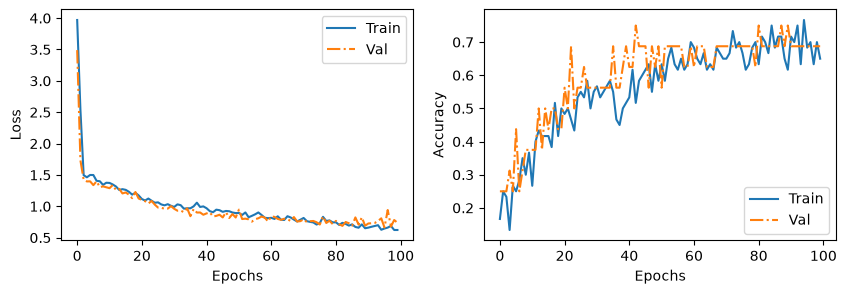

In [314]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15),  # Zufällige Drehung um bis zu 15 Grad
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [315]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [319]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.625
Precision: 0.4861111111111111
Recall   : 0.625
F1       : 0.5416666666666666


c:\Users\fabia\miniconda3\envs\ki_projekt\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


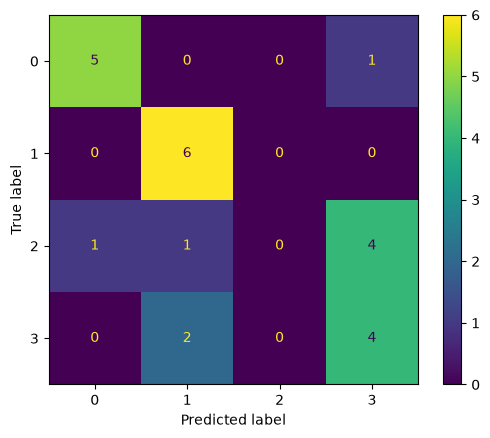

In [285]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe e): Early Stopping

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 3.9416025
	Train Acc.	 0.16666666666666666
	Val Loss	 3.4135547
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 2.5180573
	Train Acc.	 0.21666666666666667
	Val Loss	 1.7160872
	Val Acc.	 0.1875
Epoch 3 from 100
	Train Loss	 1.6339068
	Train Acc.	 0.2
	Val Loss	 1.412112
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.4912285
	Train Acc.	 0.21666666666666667
	Val Loss	 1.3644924
	Val Acc.	 0.3125
Epoch 5 from 100
	Train Loss	 1.42914
	Train Acc.	 0.25
	Val Loss	 1.3762901
	Val Acc.	 0.3125
	--> Keine Verbesserung seit 1/10 Epochen.
Epoch 6 from 100
	Train Loss	 1.4088922
	Train Acc.	 0.31666666666666665
	Val Loss	 1.3284708
	Val Acc.	 0.4375
Epoch 7 from 100
	Train Loss	 1.4278282
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3385425
	Val Acc.	 0.3125
	--> Keine Verbesserung seit 1/10 Epochen.
Epoch 8 from 100
	Train Loss	 1.3817397
	Train Acc.	 0.31666666666666665
	Val Loss	 1.3253946
	Val Acc.	 0.375
Epoch 9 from 100
	Train 

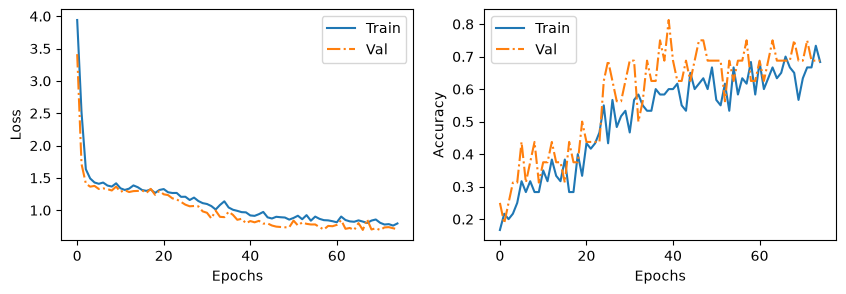

In [324]:
# Setting y_train, yval, y_test labels for the dataset
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001

# Early Stopping Einstellungen
patience = 10          # Wie viele Epochen das Netz ohne Verbesserung weiterlaufen darf
best_val_loss = np.inf # Startwert für den besten Fehler (wird kontinuierlich überschrieben)
patience_counter = 0   # Zähler, der hochzählt, wenn der Loss stagniert
best_model_wts = None  # Hierdrin parken wir das "Gehirn" des Modells im besten Zustand


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15),  # Zufällige Drehung um bis zu 15 Grad
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)
    
    ### EARLY STOPPING CHECK ###
    if val_loss_iter < best_val_loss:
        best_val_loss = val_loss_iter
        # STATT COPY: Wir nutzen PyTorchs eigenen Klon-Befehl für Tensors
        best_model_wts = {k: v.clone() for k, v in net.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"\t--> Keine Verbesserung seit {patience_counter}/{patience} Epochen.")
        
    if patience_counter >= patience:
        print(f"\n[Early Stopping] Training vorzeitig abgebrochen in Epoche {epoch+1}!")
        break

if best_model_wts is not None:
    net.load_state_dict(best_model_wts)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [325]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [326]:
# 2. Deine Metriken berechnen und ausgeben
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.625
Precision: 0.5011363636363636
Recall   : 0.625
F1       : 0.5431627196333079


c:\Users\fabia\miniconda3\envs\ki_projekt\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


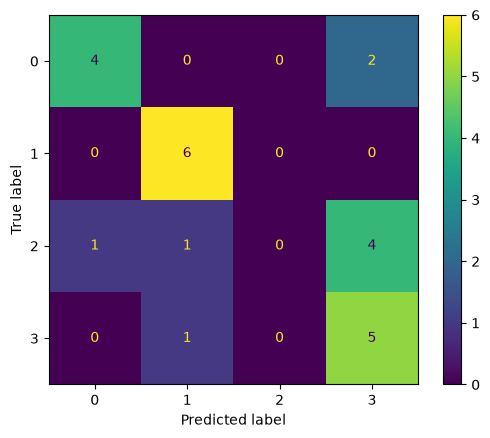

In [327]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()